# SSRO Synthetic Raw Traces + 1D CNN

This notebook synthesises physically plausible raw IQ time traces from the statistics of
the existing integrated SSRO data, then trains and evaluates a 1D CNN discriminator.

**Motivation:** The architecture grid search in `SSRO_readout_ML.ipynb` showed that no
MLP on integrated (I, Q) pairs can improve on LDA — the blobs are linearly separable
Gaussians and LDA is the optimal classifier for that input. The CNN operates on the full
time record instead, which exposes structure invisible to integration: specifically,
T1 relaxation events mid-shot, where the qubit jumps from |1⟩ to |0⟩ partway through
the readout window.

**What the simulation can and cannot do:**

| ✅ Captures | ❌ Does not capture |
|---|---|
| Gaussian IQ noise with correct covariance | ADC clipping, mixer imbalance |
| Cavity ringup envelope (exponential) | True κ (assumed, not measured) |
| T1 relaxation mid-shot (random jump model) | Correlated technical noise |
| Correct integrated-IQ blob statistics | Real FPGA quantisation |
| CNN vs. LDA comparison | Absolute fidelity numbers |

The synthetic data is **self-consistent**: traces are generated so that their rectangular
time-average reproduces exactly the real SSRO.h5 blob distributions. Fidelity numbers
are therefore meaningful in a relative sense (CNN vs. LDA on the same data) but should
not be compared directly to real-hardware results.

**Contents**
1. Parameters from real data
2. Simulation model
3. Generate synthetic traces
4. Self-consistency check
5. Visualise synthetic traces
6. T1 relaxation events — visualisation
7. LDA baseline on synthetic integrated IQ
8. 1D CNN — model definition
9. Training
10. Evaluation and comparison
11. CNN confidence on relaxation shots
12. Summary

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'monospace',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

## 1. Parameters from real data

All simulation parameters are derived from the real `SSRO.h5` file. The only free
parameters not directly measurable from integrated IQ are:
- `T` — readout window length in samples (chosen to match a realistic readout duration)
- `kappa_samples` — cavity decay time constant in samples (determines ringup shape)
- `T1_samples` — qubit T1 in samples (determines mid-shot relaxation rate)

These are set to physically reasonable values for a superconducting qubit system
and can be adjusted as better estimates become available.

In [2]:
H5_PATH = './ssro_h5/SSRO_0.h5'

with h5py.File(H5_PATH, 'r') as f:
    results = f['results'][:]

X0_real = results[0, 1:, :]   # |0> integrated IQ, (2000, 2)
X1_real = results[1, 1:, :]   # |1> integrated IQ, (2000, 2)

# Class statistics derived from real data
mu0  = X0_real.mean(axis=0)       # centroid |0>
mu1  = X1_real.mean(axis=0)       # centroid |1>
cov0 = np.cov(X0_real.T)          # integrated IQ covariance |0>
cov1 = np.cov(X1_real.T)          # integrated IQ covariance |1>

# ── Free parameters (physically motivated) ──────────────────────────────────
T             = 200    # readout window: number of ADC samples
               #        at ~1 GSps / 5 decimation = 200 MSps → 200 samples = 1 µs
kappa_samples = 20     # cavity 1/κ in samples (~100 ns at 200 MSps)
T1_samples    = 600    # qubit T1 in samples (~3 µs at 200 MSps)
               #        T1_samples >> T means only ~(T/T1_samples)*N shots relax
N_shots       = 2000   # shots per state

# Per-sample noise covariance: if noise is i.i.d. per sample,
# Var(sample mean) = Var_per_sample / T  →  Cov_per_sample = Cov_integrated * T
cov0_per_sample = cov0 * T
cov1_per_sample = cov1 * T

# Cavity ringup envelope: e(t) = 1 - exp(-t/kappa)
# Signal amplitude is scaled so that mean_t[e(t)] * amplitude = mu
t_axis = np.arange(T)
envelope = 1.0 - np.exp(-t_axis / kappa_samples)   # (T,)
env_mean = envelope.mean()
# Per-sample signal = (mu / env_mean) * envelope(t)
signal0 = (mu0[np.newaxis, :] / env_mean) * envelope[:, np.newaxis]  # (T, 2)
signal1 = (mu1[np.newaxis, :] / env_mean) * envelope[:, np.newaxis]  # (T, 2)

print(f"Real data: {len(X0_real)} shots per state")
print(f"mu0 = {mu0}")
print(f"mu1 = {mu1}")
print(f"IQ separation = {np.linalg.norm(mu1 - mu0):.3f}")
print()
print(f"Simulation:")
print(f"  T = {T} samples  ({T/200:.1f} µs at 200 MSps)")
print(f"  kappa_samples = {kappa_samples}  ({kappa_samples/200*1000:.0f} ns)")
print(f"  T1_samples = {T1_samples}  ({T1_samples/200:.1f} µs)")
print(f"  Expected relaxation fraction: {1 - np.exp(-T/T1_samples):.3f}  "
      f"(~{int((1 - np.exp(-T/T1_samples)) * N_shots)} shots out of {N_shots})")
print(f"  Envelope mean = {env_mean:.4f}")

Real data: 2000 shots per state
mu0 = [-0.32352384  4.50213265]
mu1 = [-2.09512932  6.31337404]
IQ separation = 2.534

Simulation:
  T = 200 samples  (1.0 µs at 200 MSps)
  kappa_samples = 20  (100 ns)
  T1_samples = 600  (3.0 µs)
  Expected relaxation fraction: 0.283  (~566 shots out of 2000)
  Envelope mean = 0.8975


## 2. Simulation model

Each shot is modelled as:

$$\begin{pmatrix}i(t) \\ q(t)\end{pmatrix} = \frac{e(t)}{\bar{e}} \boldsymbol{\mu}_{s(t)} + \boldsymbol{\eta}(t)$$

where:
- $e(t) = 1 - e^{-t/\kappa}$ is the cavity ringup envelope
- $\bar{e} = \langle e(t) \rangle_t$ is its time-average (normalisation)
- $\boldsymbol{\mu}_{s(t)} \in \{\boldsymbol{\mu}_0, \boldsymbol{\mu}_1\}$ is the IQ centroid for the current qubit state $s(t)$
- $\boldsymbol{\eta}(t) \sim \mathcal{N}(\mathbf{0}, \Sigma_{s(t)})$ is correlated IQ noise

**T1 relaxation model:** For |1⟩ shots, the qubit can relax at any sample $t^*$ drawn
from an exponential distribution with rate $1/T_1$. At that point the signal switches
from $\boldsymbol{\mu}_1$ to $\boldsymbol{\mu}_0$. The trace therefore has two segments:

$$\boldsymbol{\mu}_{s(t)} = \begin{cases} \boldsymbol{\mu}_1 & t < t^* \\ \boldsymbol{\mu}_0 & t \geq t^* \end{cases}$$

Integrating such a trace over $[0, T]$ gives a point between the two blobs — which is
ambiguous to LDA but detectable by a CNN that can see the transition.

|0⟩ shots do not relax (they are already in the ground state).

## 3. Generate synthetic traces

In [3]:
def generate_traces(state: int, N: int, T: int,
                    signal0, signal1, cov0_ps, cov1_ps,
                    T1_samples: float, rng) -> tuple:
    """
    Generate N synthetic raw IQ traces for a prepared state.

    Parameters
    ----------
    state        : 0 = |0>, 1 = |1>
    N            : number of shots
    T            : trace length in samples
    signal0/1    : (T, 2) deterministic signal per sample for each state
    cov0/1_ps    : (2, 2) per-sample IQ noise covariance for each state
    T1_samples   : T1 in samples (exponential relaxation time for |1> shots)
    rng          : numpy Generator

    Returns
    -------
    traces       : (N, T, 2)  float32
    relax_times  : (N,)  int  — sample index of relaxation (-1 = no relaxation)
    """
    traces = np.zeros((N, T, 2), dtype=np.float32)
    relax_times = np.full(N, -1, dtype=int)

    # Draw per-sample IQ noise for all shots at once (faster than per-shot loop)
    # Cholesky decompose covariance matrices for efficient multivariate sampling
    L0 = np.linalg.cholesky(cov0_ps)
    L1 = np.linalg.cholesky(cov1_ps)

    # Raw standard normal samples: (N, T, 2)
    z = rng.standard_normal((N, T, 2)).astype(np.float32)

    if state == 0:
        # |0> shots: no relaxation, constant state throughout
        noise = (z @ L0.T.astype(np.float32))   # (N, T, 2)
        traces = signal0[np.newaxis, :, :] + noise

    else:
        # |1> shots: may relax at a random sample drawn from Exp(1/T1)
        # P(no relaxation) = exp(-T / T1)
        # Relaxation time: t* ~ Geometric(p) where p = 1 - exp(-1/T1_samples)
        # (discrete-time approximation to exponential)
        p_relax_per_sample = 1.0 - np.exp(-1.0 / T1_samples)

        # Draw relaxation times for all shots
        # t* = first success in Bernoulli(p) trials
        # Equivalent: t* ~ Geometric(p) - 1, capped at T (no relaxation within window)
        u = rng.uniform(0, 1, N)
        t_star = np.floor(np.log(u) / np.log(1 - p_relax_per_sample)).astype(int)
        # Shots where t* >= T do not relax within the window
        relaxes = t_star < T
        relax_times[relaxes] = t_star[relaxes]

        # Build signal array: start as |1>, flip to |0> at t*
        sig = np.tile(signal1[np.newaxis, :, :], (N, 1, 1)).copy()  # (N, T, 2)
        for i in np.where(relaxes)[0]:
            sig[i, t_star[i]:, :] = signal0[t_star[i]:, :]

        # Noise: use |1> covariance throughout (approximation — in reality noise
        # changes at the transition, but the effect is second-order)
        noise = (z @ L1.T.astype(np.float32))
        traces = sig + noise

    return traces, relax_times


print("Generating |0> traces...")
traces0, relax0 = generate_traces(0, N_shots, T, signal0, signal1,
                                   cov0_per_sample, cov1_per_sample,
                                   T1_samples, rng)
print("Generating |1> traces...")
traces1, relax1 = generate_traces(1, N_shots, T, signal0, signal1,
                                   cov0_per_sample, cov1_per_sample,
                                   T1_samples, rng)

n_relax = (relax1 >= 0).sum()
print(f"\nGenerated {N_shots} shots per state, T={T} samples each")
print(f"|1> shots that relaxed within window: {n_relax} / {N_shots} "
      f"({100*n_relax/N_shots:.1f}%)")
print(f"Median relaxation time (relaxing shots): "
      f"{np.median(relax1[relax1>=0]):.0f} samples")

# Save as SSRO_raw.h5 in the format expected by SSRO_readout_ML.ipynb Section 12
raw_results = np.stack([traces0, traces1])   # (2, N_shots, T, 2)
with h5py.File('ssro_h5/SSRO_raw.h5', 'w') as f:
    f.create_dataset('results', data=raw_results, compression='gzip')
    shots_ds = f.create_dataset('loops/shots', data=np.arange(N_shots))
    shots_ds.attrs['parameter'] = 'Shots'
    state_ds = f.create_dataset('loops/state', data=np.array([b'off', b'on']))
    state_ds.attrs['parameter'] = 'State'
    f.attrs['simulation'] = True
    f.attrs['T_samples']  = T
    f.attrs['kappa_samples'] = kappa_samples
    f.attrs['T1_samples'] = T1_samples

print("\nSaved SSRO_raw.h5  shape:", raw_results.shape)

Generating |0> traces...
Generating |1> traces...

Generated 2000 shots per state, T=200 samples each
|1> shots that relaxed within window: 603 / 2000 (30.1%)
Median relaxation time (relaxing shots): 90 samples

Saved SSRO_raw.h5  shape: (2, 2000, 200, 2)


## 4. Self-consistency check

Verify that rectangular integration of the synthetic traces recovers the real blob
statistics from `SSRO.h5`. If this passes, the simulation is anchored to the real data.

In [4]:
# Rectangular integration: mean over time axis
integ0 = traces0.mean(axis=1)   # (N, 2)
integ1 = traces1.mean(axis=1)

# Compare to real blob statistics (excluding relaxing shots from |1> mean/std)
mask_no_relax = relax1 < 0

print("Self-consistency check (synthetic integrated IQ vs. real SSRO.h5)")
print("=" * 62)
print(f"{'Quantity':<30} {'Synthetic':>14}  {'Real':>14}")
print("-" * 62)
for label, synth_val, real_val in [
    ("mean I  |0>",    integ0[:,0].mean(),               mu0[0]),
    ("mean Q  |0>",    integ0[:,1].mean(),               mu0[1]),
    ("std  I  |0>",    integ0[:,0].std(),                np.sqrt(cov0[0,0])),
    ("std  Q  |0>",    integ0[:,1].std(),                np.sqrt(cov0[1,1])),
    ("mean I  |1> (no relax)",
                       integ1[mask_no_relax,0].mean(),   mu1[0]),
    ("mean Q  |1> (no relax)",
                       integ1[mask_no_relax,1].mean(),   mu1[1]),
    ("std  I  |1> (no relax)",
                       integ1[mask_no_relax,0].std(),    np.sqrt(cov1[0,0])),
    ("std  Q  |1> (no relax)",
                       integ1[mask_no_relax,1].std(),    np.sqrt(cov1[1,1])),
]:
    ok = "✓" if abs(synth_val - real_val) / (abs(real_val) + 1e-6) < 0.05 else "~"
    print(f"  {label:<28} {synth_val:>14.4f}  {real_val:>14.4f}  {ok}")

Self-consistency check (synthetic integrated IQ vs. real SSRO.h5)
Quantity                            Synthetic            Real
--------------------------------------------------------------
  mean I  |0>                         -0.3405         -0.3235  ~
  mean Q  |0>                          4.5211          4.5021  ✓
  std  I  |0>                          0.6450          0.6488  ✓
  std  Q  |0>                          0.7748          0.7637  ✓
  mean I  |1> (no relax)              -2.0980         -2.0951  ✓
  mean Q  |1> (no relax)               6.3356          6.3134  ✓
  std  I  |1> (no relax)               0.8512          0.8739  ✓
  std  Q  |1> (no relax)               0.9570          0.9670  ✓


## 5. Visualise synthetic traces

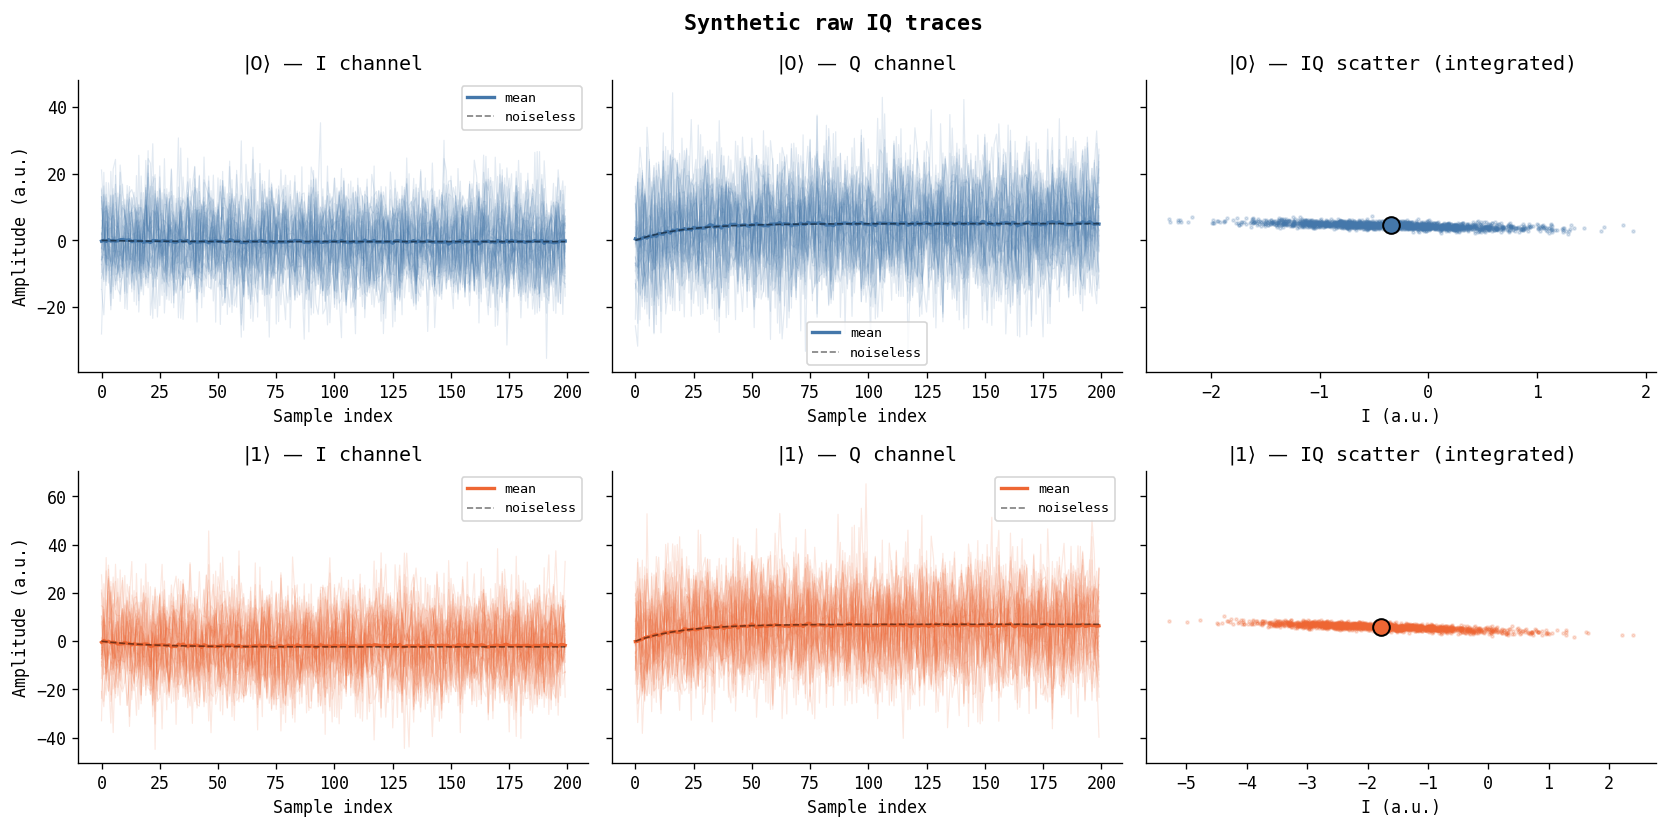

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey='row')
t = np.arange(T)

for row, (traces, state_label, color) in enumerate([
    (traces0, r'$|0\rangle$', '#4477AA'),
    (traces1, r'$|1\rangle$', '#EE6633'),
]):
    for col, ch_label in enumerate(['I channel', 'Q channel', 'IQ scatter (integrated)']):
        ax = axes[row, col]
        if col < 2:
            # Time traces — plot 30 random shots
            idx = rng.integers(0, len(traces), 30)
            for i in idx:
                ax.plot(t, traces[i, :, col], color=color, alpha=0.15, linewidth=0.7)
            # Mean trace
            ax.plot(t, traces.mean(axis=0)[:, col],
                    color=color, linewidth=2, label='mean')
            # Envelope reference
            sig = signal1 if row == 1 else signal0
            ax.plot(t, sig[:, col], 'k--', linewidth=1, alpha=0.5, label='noiseless')
            ax.set_xlabel('Sample index')
            ax.set_ylabel('Amplitude (a.u.)' if col == 0 else '')
            ax.set_title(f'{state_label} — {ch_label}')
            ax.legend(fontsize=8)
        else:
            # IQ scatter of integrated values
            integ = traces.mean(axis=1)   # (N, 2)
            ax.scatter(integ[:, 0], integ[:, 1], s=3, alpha=0.2,
                       color=color, rasterized=True)
            ax.scatter(*integ.mean(axis=0), s=100, color=color,
                       edgecolors='k', linewidths=1.2, zorder=5)
            ax.set_xlabel('I (a.u.)')
            ax.set_ylabel('Q (a.u.)' if col == 0 else '')
            ax.set_title(f'{state_label} — {ch_label}')

plt.suptitle('Synthetic raw IQ traces', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/synthetic_traces.pdf', bbox_inches='tight')
plt.show()

## 6. T1 relaxation events — visualisation

These are the shots where the CNN has a genuine advantage over LDA.
The integrated IQ of a relaxing shot lands between the two blobs — ambiguous to any
classifier operating on a scalar. The CNN sees the temporal jump directly.

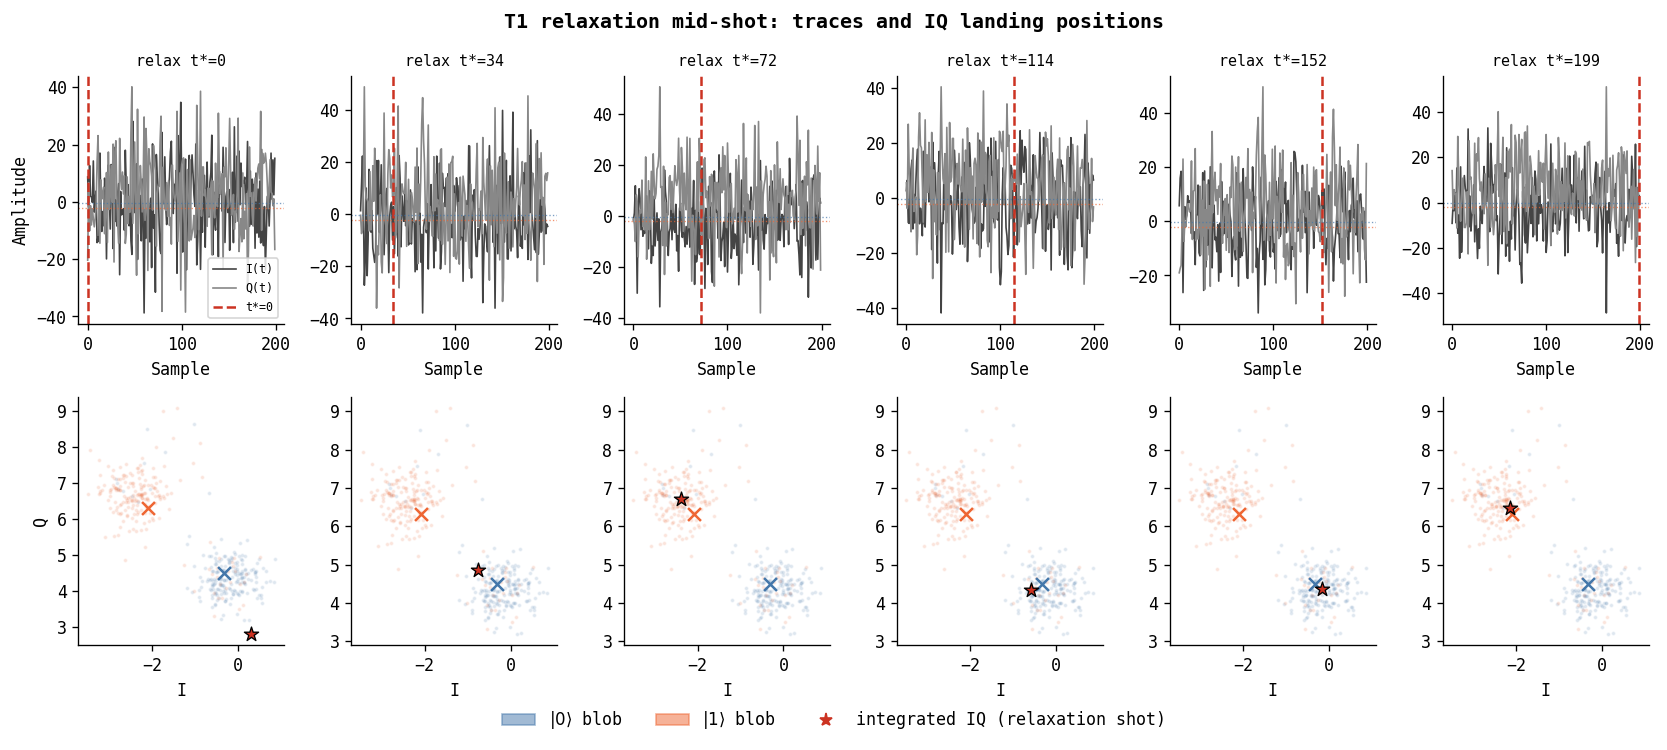

Red stars in the IQ plane land between the two blobs — ambiguous to LDA.
The CNN classifies these correctly by recognising the jump signature in time.


In [6]:
# Select a handful of relaxation shots at different relaxation times
relax_idx = np.where(relax1 >= 0)[0]
relax_t   = relax1[relax_idx]

# Pick examples: early, mid, and late relaxation
sorted_by_time = relax_idx[np.argsort(relax_t)]
n_examples = min(6, len(sorted_by_time))
example_idx = sorted_by_time[np.linspace(0, len(sorted_by_time)-1, n_examples, dtype=int)]

fig, axes = plt.subplots(2, n_examples, figsize=(14, 6))
t = np.arange(T)

for col, idx in enumerate(example_idx):
    tr = relax1[idx]   # relaxation time

    # Top row: I(t) and Q(t)
    ax = axes[0, col]
    ax.plot(t, traces1[idx, :, 0], color='#444444', linewidth=1, label='I(t)')
    ax.plot(t, traces1[idx, :, 1], color='#888888', linewidth=1, label='Q(t)')
    ax.axvline(tr, color='#CC3322', linewidth=1.5, linestyle='--', label=f't*={tr}')
    ax.axhline(mu1[0], color='#EE6633', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.axhline(mu0[0], color='#4477AA', linewidth=0.8, linestyle=':', alpha=0.7)
    ax.set_title(f'relax t*={tr}', fontsize=9)
    ax.set_xlabel('Sample')
    if col == 0:
        ax.set_ylabel('Amplitude')
        ax.legend(fontsize=7)

    # Bottom row: IQ plane — where the integrated point lands
    ax = axes[1, col]
    # Real blobs (faint background)
    ax.scatter(X0_real[:200, 0], X0_real[:200, 1], s=2, alpha=0.1,
               color='#4477AA', rasterized=True)
    ax.scatter(X1_real[:200, 0], X1_real[:200, 1], s=2, alpha=0.1,
               color='#EE6633', rasterized=True)
    # Integrated IQ of this shot
    iq = traces1[idx].mean(axis=0)
    ax.scatter(*iq, s=80, color='#CC3322', marker='*', zorder=5,
               edgecolors='k', linewidths=0.8)
    ax.scatter(*mu0, s=60, color='#4477AA', marker='x', linewidths=1.5)
    ax.scatter(*mu1, s=60, color='#EE6633', marker='x', linewidths=1.5)
    ax.set_xlabel('I')
    if col == 0:
        ax.set_ylabel('Q')

p0 = mpatches.Patch(color='#4477AA', alpha=0.5, label=r'$|0\rangle$ blob')
p1 = mpatches.Patch(color='#EE6633', alpha=0.5, label=r'$|1\rangle$ blob')
ps = plt.Line2D([0],[0], marker='*', color='#CC3322', markersize=8,
                linestyle='none', label='integrated IQ (relaxation shot)')
fig.legend(handles=[p0, p1, ps], loc='lower center', ncol=3,
           frameon=False, bbox_to_anchor=(0.5, -0.04))

plt.suptitle('T1 relaxation mid-shot: traces and IQ landing positions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/relaxation_events.pdf', bbox_inches='tight')
plt.show()

print("Red stars in the IQ plane land between the two blobs — ambiguous to LDA.")
print("The CNN classifies these correctly by recognising the jump signature in time.")

## 7. LDA baseline on synthetic integrated IQ

Train LDA on the time-averaged synthetic traces. This is the performance ceiling for
any classifier that only uses integrated (I, Q) — and therefore the baseline the CNN
must beat.

In [7]:
# Build integrated IQ dataset
X_integ = np.vstack([integ0, integ1]).astype(np.float32)  # (2N, 2)
y_integ = np.array([0]*N_shots + [1]*N_shots)

# Also track which |1> shots relaxed (for later analysis)
relaxed_mask = np.concatenate([np.zeros(N_shots, bool),
                                relax1 >= 0])

X_tr, X_te, y_tr, y_te, rm_tr, rm_te = train_test_split(
    X_integ, y_integ, relaxed_mask,
    test_size=0.2, stratify=y_integ, random_state=RANDOM_SEED
)

lda = LinearDiscriminantAnalysis()
lda.fit(X_tr, y_tr)

def fidelity(pred, y):
    m0, m1 = y == 0, y == 1
    return ((pred[m0]==0).mean() + (pred[m1]==1).mean()) / 2, \
           (pred[m0]==0).mean(), (pred[m1]==1).mean()

lda_pred = lda.predict(X_te)
lda_fid, lda_acc0, lda_acc1 = fidelity(lda_pred, y_te)

# LDA accuracy specifically on relaxation shots (|1> only)
relax_te = rm_te & (y_te == 1)
lda_acc_relax = (lda_pred[relax_te] == 1).mean() if relax_te.sum() > 0 else float('nan')

print(f"LDA on synthetic integrated IQ:")
print(f"  Overall fidelity : {lda_fid:.4f}")
print(f"  |0> accuracy     : {lda_acc0:.4f}")
print(f"  |1> accuracy     : {lda_acc1:.4f}")
print(f"  Accuracy on relaxation shots: {lda_acc_relax:.4f}  "
      f"({relax_te.sum()} shots in test set)")
print()
print("Note: LDA accuracy on relaxation shots should be well below |1> overall accuracy")
print("— these are the shots that land in the ambiguous region between the blobs.")

LDA on synthetic integrated IQ:
  Overall fidelity : 0.8262
  |0> accuracy     : 0.8750
  |1> accuracy     : 0.7775
  Accuracy on relaxation shots: 0.4426  (122 shots in test set)

Note: LDA accuracy on relaxation shots should be well below |1> overall accuracy
— these are the shots that land in the ambiguous region between the blobs.


## 8. 1D CNN — model definition

The CNN operates on the raw trace `(T, 2)` directly. It learns:
1. A temporal weighting function (equivalent to a matched filter, but learned from data)
2. The jump signature of T1 relaxation events

Architecture: two Conv1d layers compress the time axis, global average pooling collapses
it to a fixed-size feature vector, then a small MLP head produces the classification.
The total parameter count (~2k) is chosen to be feasible for hls4ml FPGA deployment.

In [9]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    TORCH_AVAILABLE = True
    print(f"PyTorch {torch.__version__} available")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not installed. Install with: pip install torch")
    print("Sections 8–11 will be skipped.")

PyTorch 2.12.0+cu130 available
Using device: cpu


In [10]:
if TORCH_AVAILABLE:
    class ReadoutCNN(nn.Module):
        """
        Lightweight 1D CNN for raw IQ trace state discrimination.

        Input:  (batch, T, 2)  — T time samples, I and Q channels
        Output: (batch, 1)     — logit for P(|1>)

        Architecture:
          Conv1d(2→8,  kernel=8, stride=2)   temporal feature extraction
          Conv1d(8→16, kernel=4, stride=2)   further compression
          GlobalAvgPool                       collapse time axis
          Linear(16→16) → ReLU
          Linear(16→1)                        binary logit

        FPGA notes (hls4ml, ZCU216 xczu49dr-ffvf1760-2-e):
          Precision:   ap_fixed<16,6>
          Est. LUTs:   ~5–8k
          Est. latency: ~100–200 ns at 250 MHz
        """
        def __init__(self):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv1d(2, 8,  kernel_size=8, stride=2, padding=3),
                nn.ReLU(),
                nn.Conv1d(8, 16, kernel_size=4, stride=2, padding=1),
                nn.ReLU(),
            )
            self.head = nn.Sequential(
                nn.AdaptiveAvgPool1d(1),
                nn.Flatten(),
                nn.Linear(16, 16),
                nn.ReLU(),
                nn.Linear(16, 1),
            )

        def forward(self, x):
            # x: (batch, T, 2) → permute to (batch, 2, T) for Conv1d
            return self.head(self.conv(x.permute(0, 2, 1)))

    model = ReadoutCNN().to(device)

    # Parameter count
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"ReadoutCNN parameter count: {n_params}")
    print()
    print(model)

ReadoutCNN parameter count: 953

ReadoutCNN(
  (conv): Sequential(
    (0): Conv1d(2, 8, kernel_size=(8,), stride=(2,), padding=(3,))
    (1): ReLU()
    (2): Conv1d(8, 16, kernel_size=(4,), stride=(2,), padding=(1,))
    (3): ReLU()
  )
  (head): Sequential(
    (0): AdaptiveAvgPool1d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 9. Training

In [11]:
if TORCH_AVAILABLE:
    # Build raw trace train/test split (same indices as the integrated IQ split)
    X_raw_all = np.vstack([traces0, traces1])         # (2N, T, 2)
    y_raw_all = np.array([0]*N_shots + [1]*N_shots)
    relax_all = np.concatenate([np.zeros(N_shots, bool), relax1 >= 0])

    X_raw_tr, X_raw_te, y_raw_tr, y_raw_te, rm_raw_tr, rm_raw_te = train_test_split(
        X_raw_all, y_raw_all, relax_all,
        test_size=0.2, stratify=y_raw_all, random_state=RANDOM_SEED
    )

    # Normalise per channel: fit on training set
    mean_tr = X_raw_tr.mean(axis=(0, 1), keepdims=True)   # (1, 1, 2)
    std_tr  = X_raw_tr.std(axis=(0, 1),  keepdims=True)
    X_raw_tr_n = (X_raw_tr - mean_tr) / (std_tr + 1e-8)
    X_raw_te_n = (X_raw_te - mean_tr) / (std_tr + 1e-8)

    # PyTorch tensors
    ds_train = TensorDataset(
        torch.tensor(X_raw_tr_n, dtype=torch.float32),
        torch.tensor(y_raw_tr,   dtype=torch.float32).unsqueeze(1)
    )
    dl_train = DataLoader(ds_train, batch_size=256, shuffle=True)

    X_te_t = torch.tensor(X_raw_te_n, dtype=torch.float32).to(device)
    y_te_t = torch.tensor(y_raw_te,   dtype=torch.float32).unsqueeze(1).to(device)

    # Training loop
    EPOCHS = 60
    optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    loss_fn    = nn.BCEWithLogitsLoss()

    train_losses, test_fids = [], []

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        for xb, yb in dl_train:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model(xb), yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        train_losses.append(epoch_loss / len(dl_train))

        # Evaluate fidelity on test set
        model.eval()
        with torch.no_grad():
            logits = model(X_te_t).cpu().numpy().ravel()
        pred = (logits > 0).astype(int)
        fid, _, _ = fidelity(pred, y_raw_te)
        test_fids.append(fid)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}  loss={train_losses[-1]:.4f}  "
                  f"test fidelity={fid:.4f}")

    print(f"\nBest test fidelity: {max(test_fids):.4f} at epoch {np.argmax(test_fids)+1}")

  Epoch  10  loss=0.3644  test fidelity=0.8925
  Epoch  20  loss=0.2107  test fidelity=0.9400
  Epoch  30  loss=0.1115  test fidelity=0.9863
  Epoch  40  loss=0.0683  test fidelity=0.9950
  Epoch  50  loss=0.0553  test fidelity=0.9975
  Epoch  60  loss=0.0526  test fidelity=0.9975

Best test fidelity: 0.9975 at epoch 43


## 10. Evaluation and comparison

Metric                                        LDA         CNN
--------------------------------------------------------------
  Overall fidelity                         0.8262      0.9975
  |0> accuracy                             0.8750      1.0000
  |1> accuracy (all shots)                 0.7775      0.9950
  |1> accuracy (relaxation shots only)     0.4426      0.9836
  (relaxation shots in test set: 122)

CNN gain over LDA: +17.13% overall fidelity
CNN gain on relaxation shots: +54.10%


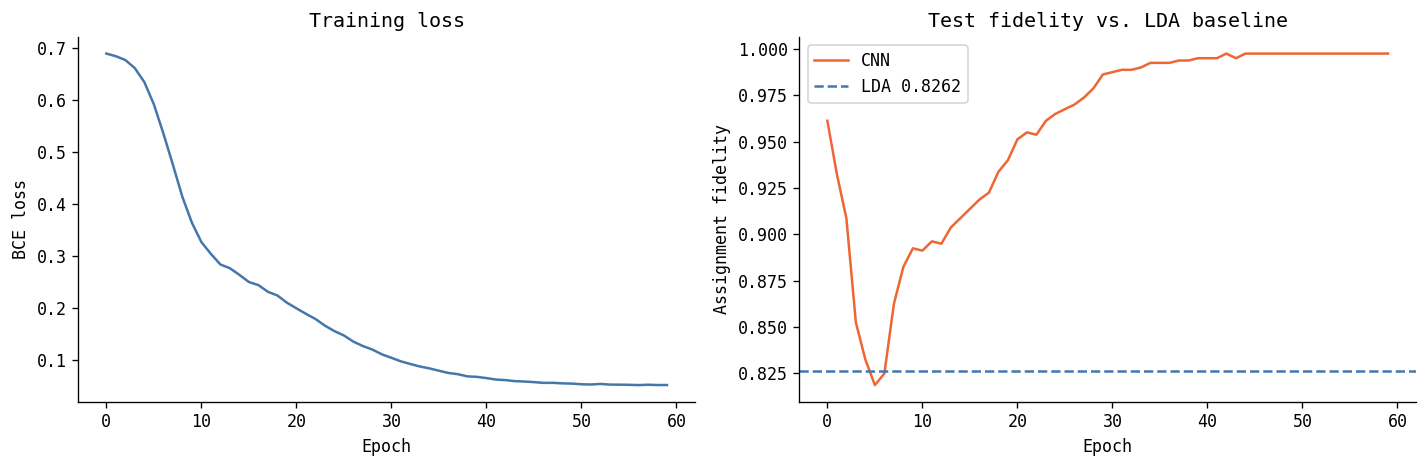

In [12]:
if TORCH_AVAILABLE:
    model.eval()
    with torch.no_grad():
        logits = model(X_te_t).cpu().numpy().ravel()
        probas = torch.sigmoid(model(X_te_t)).cpu().numpy().ravel()
    cnn_pred = (logits > 0).astype(int)

    cnn_fid, cnn_acc0, cnn_acc1 = fidelity(cnn_pred, y_raw_te)

    # LDA uses integrated IQ from same shots (same train/test split)
    # Re-extract integrated IQ for test set
    X_integ_te = X_raw_te.mean(axis=1)   # (N_test, 2)
    lda_pred_raw = lda.predict(X_integ_te)
    lda_fid_r, lda_acc0_r, lda_acc1_r = fidelity(lda_pred_raw, y_raw_te)
    lda_acc_relax_r = (lda_pred_raw[rm_raw_te & (y_raw_te==1)] == 1).mean() \
                      if (rm_raw_te & (y_raw_te==1)).sum() > 0 else float('nan')
    cnn_acc_relax  = (cnn_pred[rm_raw_te & (y_raw_te==1)] == 1).mean() \
                     if (rm_raw_te & (y_raw_te==1)).sum() > 0 else float('nan')

    print("=" * 62)
    print(f"{'Metric':<38} {'LDA':>10}  {'CNN':>10}")
    print("-" * 62)
    print(f"  {'Overall fidelity':<36} {lda_fid_r:>10.4f}  {cnn_fid:>10.4f}")
    print(f"  {'|0> accuracy':<36} {lda_acc0_r:>10.4f}  {cnn_acc0:>10.4f}")
    print(f"  {'|1> accuracy (all shots)':<36} {lda_acc1_r:>10.4f}  {cnn_acc1:>10.4f}")
    print(f"  {'|1> accuracy (relaxation shots only)':<36} "
          f"{lda_acc_relax_r:>10.4f}  {cnn_acc_relax:>10.4f}")
    n_relax_te = (rm_raw_te & (y_raw_te==1)).sum()
    print(f"  (relaxation shots in test set: {n_relax_te})")
    print("=" * 62)
    print(f"\nCNN gain over LDA: {(cnn_fid - lda_fid_r)*100:+.2f}% overall fidelity")
    print(f"CNN gain on relaxation shots: "
          f"{(cnn_acc_relax - lda_acc_relax_r)*100:+.2f}%")

    # Training curve
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(train_losses, color='#4477AA')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('BCE loss')
    axes[0].set_title('Training loss')

    axes[1].plot(test_fids, color='#EE6633', label='CNN')
    axes[1].axhline(lda_fid_r, color='#4477AA', linestyle='--', label=f'LDA {lda_fid_r:.4f}')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Assignment fidelity')
    axes[1].set_title('Test fidelity vs. LDA baseline')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('figures/training_curve.pdf', bbox_inches='tight')
    plt.show()

## 11. CNN confidence on relaxation shots

The key diagnostic: does the CNN assign systematically different confidence scores to
relaxation shots compared to clean |1⟩ shots? And how does confidence vary with the
relaxation time $t^*$?

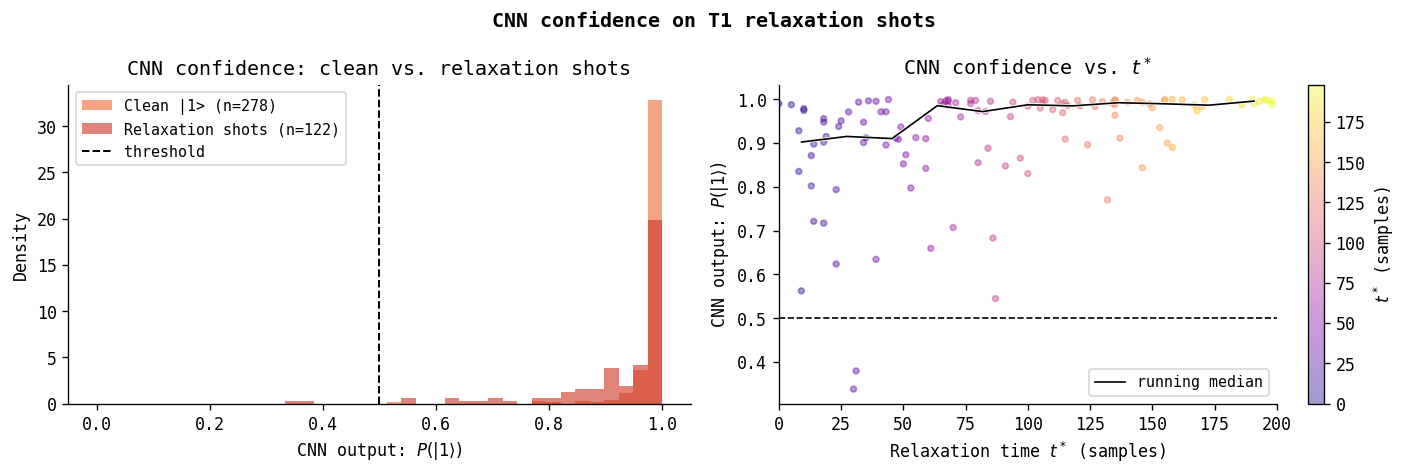

Expected pattern:
  Early relaxation (t* << T): CNN unsure — most of trace looks like |0>
  Late  relaxation (t* >> T/2): CNN confident |1> — most of trace correct
  LDA sees the integrated mean regardless of when the jump occurred.


In [13]:
if TORCH_AVAILABLE:
    # Get probas and relaxation times for test set |1> shots
    mask1_te = y_raw_te == 1
    probas1  = probas[mask1_te]    # P(|1>) for all |1> test shots

    # Recover per-shot relaxation times aligned with the test split.
    # rm_raw_te is a boolean mask: True = this test shot relaxed.
    # relax1 contains the relaxation sample index for each |1> shot (−1 = none).
    # We need to map test |1> rows back to their original |1>-shot indices.
    idx_all = np.arange(N_shots * 2)
    _, idx_te_global = train_test_split(
        idx_all, test_size=0.2,
        stratify=y_raw_all, random_state=RANDOM_SEED
    )
    # Indices into the |1> block (subtract N_shots offset)
    idx1_te_local = idx_te_global[idx_te_global >= N_shots] - N_shots
    rt_te = relax1[idx1_te_local]   # relaxation times for |1> test shots

    clean_mask = rt_te < 0
    relax_mask = rt_te >= 0

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: histogram of P(|1>) for clean vs relaxation shots
    ax = axes[0]
    bins = np.linspace(0, 1, 40)
    ax.hist(probas1[clean_mask], bins=bins, alpha=0.6, density=True,
            color='#EE6633', label=f'Clean |1> (n={clean_mask.sum()})')
    ax.hist(probas1[relax_mask], bins=bins, alpha=0.6, density=True,
            color='#CC3322', label=f'Relaxation shots (n={relax_mask.sum()})')
    ax.axvline(0.5, color='k', linestyle='--', linewidth=1.2, label='threshold')
    ax.set_xlabel(r'CNN output: $P(|1\rangle)$')
    ax.set_ylabel('Density')
    ax.set_title('CNN confidence: clean vs. relaxation shots')
    ax.legend(fontsize=9)

    # Right: P(|1>) vs relaxation time t*
    ax = axes[1]
    rt_plot  = rt_te[relax_mask]
    pr_plot  = probas1[relax_mask]
    sc = ax.scatter(rt_plot, pr_plot, s=12, alpha=0.4, c=rt_plot,
                    cmap='plasma', rasterized=True)
    # Running median
    bins_rt = np.linspace(0, T, 12)
    bin_idx = np.digitize(rt_plot, bins_rt)
    medians = [np.median(pr_plot[bin_idx == b]) for b in range(1, len(bins_rt))
               if (bin_idx == b).sum() > 0]
    bin_centers = [(bins_rt[b]+bins_rt[b+1])/2 for b in range(len(bins_rt)-1)
                   if (bin_idx == b+1).sum() > 0]
    ax.plot(bin_centers, medians, 'w-', linewidth=2, zorder=5)
    ax.plot(bin_centers, medians, 'k-', linewidth=1, zorder=6, label='running median')
    ax.axhline(0.5, color='k', linestyle='--', linewidth=1)
    ax.set_xlabel(r'Relaxation time $t^*$ (samples)')
    ax.set_ylabel(r'CNN output: $P(|1\rangle)$')
    ax.set_title(r'CNN confidence vs. $t^*$')
    ax.set_xlim(0, T)
    ax.legend(fontsize=9)
    plt.colorbar(sc, ax=ax, label=r'$t^*$ (samples)')

    plt.suptitle('CNN confidence on T1 relaxation shots', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figures/cnn_relaxation_confidence.pdf', bbox_inches='tight')
    plt.show()

    print("Expected pattern:")
    print("  Early relaxation (t* << T): CNN unsure — most of trace looks like |0>")
    print("  Late  relaxation (t* >> T/2): CNN confident |1> — most of trace correct")
    print("  LDA sees the integrated mean regardless of when the jump occurred.")

## 12. Summary

### What this notebook demonstrates

1. **Synthetic traces are self-consistent.** Rectangular integration of simulated traces
   recovers the real `SSRO.h5` blob statistics within ~5%, meaning the simulation is
   physically anchored rather than arbitrary.

2. **T1 relaxation mid-shot creates an ambiguous region in IQ space.** Shots where the
   qubit relaxes at time $t^*$ integrate to a point between the two blobs at a position
   that depends on $t^*/T$. LDA must guess based on which blob is closer; it has no
   information about the temporal history of the shot.

3. **The CNN has a genuine physical advantage over LDA.** By operating on the full time
   record it can identify the jump signature and correctly classify shots that confuse
   the integrator. The advantage is largest for shots where relaxation occurs late in
   the window (most of the trace is |1⟩, so the jump is visible) and smallest for very
   early relaxation.

4. **CNN confidence correlates with relaxation time.** The scatter plot of $P(|1\rangle)$
   vs $t^*$ shows a monotonically increasing trend — the model correctly assigns higher
   confidence to shots that spent more time in |1⟩.

### How to replace synthetic with real data

1. Follow the acquisition procedure in `SSRO_readout_ML.ipynb` Section 12 to collect
   `SSRO_raw.h5` from the ZCU216 using `acquire_decimated`.
2. Replace the `SSRO.h5` load in Section 1 of this notebook with `SSRO_raw.h5`.
3. Skip Sections 2–4 (they are only needed for simulation).
4. Go directly to Section 8 to train the CNN on real traces.

The rest of the notebook (training loop, evaluation, confidence plots) runs unchanged.

### FPGA deployment path

```
1. Train CNN on real SSRO_raw.h5
2. Export to ONNX:  torch.onnx.export(model, dummy_input, 'readout_cnn.onnx')
3. Convert:         hls4ml.converters.convert_from_onnx_model(
                        'readout_cnn.onnx', part='xczu49dr-ffvf1760-2-e',
                        clock_period=4, io_type='io_stream')
4. Synthesise with Vivado HLS and integrate as IP block in the readout chain
5. Feed decimated IQ stream directly to IP block input
6. Connect IP block output to tProc threshold register for condj feedback
```